In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
import pandas as pd

/home/nilsmk/.conda/envs/nils_production-10-2022_rhel8/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [ ]:
read_one_case  = False
plot_corrected = False

In [ ]:
commondir = '/lustre/storeB/users/nilsmk/anemoi-stormsurge/output'

In [ ]:
# Exps: (foldername, shortname, nc_filepattern)
exps_anemoi = [('longrun_10years_newgraph_90s_uncorr', 'train16yr_uncorr_10d_100k', '????-??-??_240h_step100000.nc'), 
               ('longrun_10years_newgraph_90s_corrected', 'train16yr_corr_10d_100k', '????-??-??_240h_step100000.nc'),
               ('longrun_10years_newgraph_90s_uncorr', 'train16yr_uncorr_1year_100k', '????-??-??_1year_step100000.nc'), 
               ('longrun_10years_newgraph_90s_corrected', 'train16yr_corr_1year_100k', '????-??-??_1year_step100000.nc'),
            #    ('longrun_graph10.3_1980-2012', 'train30yr_10d_183k', '*_10day_step183000.nc'), 
            #    ('longrun_graph10.3_1980-2012', 'train30yr_1y_149k', '*_1year_step149000.nc'), 
               ('longrun_5years_newgraph_90s_uncorr', 'train5yr_uncorr_10d_25k', '????-??-??_240h_step025000.nc'),
               ('longrun_5years_newgraph_90s_uncorr', 'train5yr_uncorr_1year_25k', '????-??-??_1year_step025000.nc'),
               ('longrun_5years_newgraph_90s_uncorr', 'train5yr_uncorr_10d_50k', '????-??-??_240h_step050000.nc'),
               ('longrun_5years_newgraph_90s_uncorr', 'train5yr_uncorr_1year_50k', '????-??-??_1year_step050000.nc'),
            #    ('longrun_5years_newgraph_90s_uncorr', 'train5yr_uncorr_10d_100k', '????-??-??_240h_step100000.nc')
            #    ('longrun_5years_newgraph_90s_uncorr', 'train5yr_uncorr_1year_100k', '????-??-??_1year_step100000.nc')
               ]


In [ ]:
# # Longrun 1980-2012:
# idir        = os.path.join(commondir, 'longrun_graph10.3_1980-2012/inference')
# odir        = os.path.join(commondir, 'longrun_graph10.3_1980-2012/inference/figures/oneyear')
# Train 16yr uncorr:
idir        = os.path.join(commondir, 'longrun_10years_newgraph_90s_uncorr/inference')
odir        = os.path.join(commondir, 'longrun_10years_newgraph_90s_uncorr/inference/figures/oneyear')
# # Train 5yr uncorr:
# idir        = os.path.join(commondir, 'longrun_5years_newgraph_90s_uncorr/inference')
# odir        = os.path.join(commondir, 'longrun_5years_newgraph_90s_uncorr/inference/figures/oneyear')
# Train 16yr corr:
# idir        = os.path.join(commondir, 'longrun_10years_newgraph_90s_corrected/inference')
# odir        = os.path.join(commondir, 'longrun_10years_newgraph_90s_corrected/inference/figures/oneyear')
# plot_corrected = True
if not os.path.exists(odir):
    os.makedirs(odir)

In [ ]:
comparewith = '/lustre/storeB/users/nilsmk/stormrisk/nora3_v2/{}/ocean_his.nc'
if plot_corrected:
    comparewith2 = '/lustre/storeB/users/nilsmk/stormrisk/nora3_v2_corrected/{}/ocean_his.nc'

In [4]:
# Create odir if it does not exist
import os
if not os.path.exists(odir):
    os.makedirs(odir)

TODO: Plot timseries for all runs, start with Cuxhaven

In [5]:
# Read obs:
idir_obs          = '/lustre/storeB/users/nilsmk/stormrisk'
ifile_tseries_obs = os.path.join(idir_obs, 'aggregated_water_level_observations_with_pytide_prediction_dataset_extended_nor_stations_with_4_nora-surge_exps.nc')
nc_timeseries_selected = xr.open_dataset(ifile_tseries_obs)

/home/nilsmk/.conda/envs/nils_production-10-2022_rhel8/lib/python3.9/site-packages/xarray/backends/plugins.py:64: RuntimeWarning: Engine 'gini' loading failed:
cannot import name 'deprecated' from 'typing_extensions' (/home/nilsmk/.conda/envs/nils_production-10-2022_rhel8/lib/python3.9/site-packages/typing_extensions.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


In [6]:
if read_one_case:
    # Cuxhaven coordinates
    # sta_lat = 53.87
    # sta_lon = 8.72
    # staname = 'Cuxhaven'
    # sta_idx = np.where(nc_timeseries_selected.stationid[:].values == 'DE_Cuxhaven')[0][0]
    # Oscarsborg coordinates 66 NO_OSC 59.678074 10.604861
    sta_lat = 59.68
    sta_lon = 10.60
    staname = 'Oscarsborg'
    sta_idx = np.where(nc_timeseries_selected.stationid[:].values == 'NO_OSC')[0][0]
    # Bergen coordinates 53 NO_BGO 60.398045 5.320487
    # sta_lat = 60.40
    # sta_lon = 5.32
    # staname = 'Bergen'
    # sta_idx = np.where(nc_timeseries_selected.stationid[:].values == 'NO_BGO')[0][0]
    # Do the same for the comparison data
    lat_c_arr = np.array(lat_c[:])
    lon_c_arr = np.array(lon_c[:])
    dist_c = np.sqrt((lat_c_arr - sta_lat)**2 + (lon_c_arr - sta_lon)**2)
    min_index_c = np.unravel_index(np.argmin(dist_c), dist_c.shape)
    print(f'Nearest point to {staname} in comparison data: lat={lat_c_arr[min_index_c]}, lon={lon_c_arr[min_index_c]} at index {min_index_c}')
    # If land point, find new position:
    if mask_c[min_index_c] == 0:
        print('Nearest point is on land, searching for nearest sea point...')
        sea_indices = np.where(mask_c == 1)
        sea_lats = lat_c_arr[sea_indices]
        sea_lons = lon_c_arr[sea_indices]
        dist_sea = np.sqrt((sea_lats - sta_lat)**2 + (sea_lons - sta_lon)**2)
        min_sea_index = np.argmin(dist_sea)
        min_index_c = (sea_indices[0][min_sea_index], sea_indices[1][min_sea_index])
        print(f'New nearest sea point: lat={lat_c_arr[min_index_c]}, lon={lon_c_arr[min_index_c]} at index {min_index_c}')
        # Update sta_lat and sta_lon
        sta_lat = lat_c_arr[min_index_c]
        sta_lon = lon_c_arr[min_index_c]
    # Find the nearest point in the lat/lon grid
    import numpy as np
    lat_arr = np.array(lat[:])
    lon_arr = np.array(lon[:])
    dist = np.sqrt((lat_arr - sta_lat)**2 + (lon_arr - sta_lon)**2)
    min_index = np.unravel_index(np.argmin(dist), dist.shape)
    print(f'Nearest point to {staname}: lat={lat_arr[min_index]}, lon={lon_arr[min_index]} at index {min_index}')
    # Read obs:
    # selected_timeseries = (nc_timeseries_selected['observation']-nc_timeseries_selected['pytide_prediction']).sel(time=slice(time[0], time[-1]))[:,sta_idx]
    selected_timeseries = nc_timeseries_selected.sel(time=slice(time[0], time[-1]))
    obs_surge = (selected_timeseries['observation']-selected_timeseries['pytide_prediction'])[sta_idx,:]*0.01  # Convert cm to m

In [7]:
if False:
    #
    # Plot the time series for the station for all inference runs and the comparison data in one plot
    fig, ax = plt.subplots(figsize=(10, 5))
    for file in ifiles:
        nc = xr.open_dataset(file)
        zeta = nc.zeta
        time = nc.time
        # Calculate RMSE for this time series compared to the comparison data
        zeta_c_series = zeta_c[time_indices, min_index_c[0], min_index_c[1]].values
        zeta_series = zeta[:, min_index[0]].values
        rmse = np.sqrt(np.mean((zeta_series - zeta_c_series)**2))
        print(f'RMSE for step {file[-9:-3]}: {rmse:.4f} m')
        ax.plot(time, zeta[:, min_index[0]], label=f'Inference CP step {file[-9:-3]}, ({rmse:.2f}m)', lw=1, alpha=0.7)
    # Plot the comparison data time series
    # ax.plot(time_c[time_indices], zeta_c[time_indices, min_index_c[0], min_index_c[1]], label='NORA Surge (comparison)', lw=2, color='k')
    # if plot_corrected:
    #     ax.plot(time_c[time_indices], zeta_c2[time_indices, min_index_c[0], min_index_c[1]], label='NORA Surge Corrected (comparison)', lw=2, color='orange')
    # Plot obs surge:
    ax.plot(selected_timeseries.time, obs_surge, label='Observed Surge', lw=2, color='green', alpha=0.7)
    ax.set_title(f'Time series at {staname} (lat={sta_lat}, lon={sta_lon})')
    ax.set_xlabel('Time')
    ax.set_ylabel('zeta [m]')
    ax.legend(fontsize='small')
    plt.savefig(os.path.join(odir, f'{prefix}zeta_timeseries_{staname}.png'), dpi=100)
    plt.show()

In [8]:
if False:
    linewdth = 1
    # Plot the individual time series
    for file in ifiles:
        print(f'Processing file: {file}')
        fig, ax = plt.subplots(figsize=(14, 4))
        # Plot obs surge:
        ax.plot(selected_timeseries.time, obs_surge, label='Observed Surge', lw=linewdth, color='green', alpha=0.7)
        nc = xr.open_dataset(file)
        zeta = nc.zeta
        time = nc.time
        zeta_series = zeta[:, min_index[0]].values
        # Calculate RMSE for this time series compared to the comparison data
        if plot_corrected:
            zeta_c_series2 = zeta_c2[time_indices, min_index_c[0], min_index_c[1]]
        zeta_c_series = zeta_c[time_indices, min_index_c[0], min_index_c[1]]
        try:
            if plot_corrected:
                rmse = np.sqrt(np.mean((zeta_series - zeta_c_series.values)**2))
            else:
                rmse = np.sqrt(np.mean((zeta_series - zeta_c_series.values)**2))
        except:
            rmse = np.nan
        ax.plot(time, zeta[:, min_index[0]], label=f'Inference CP step {file[-9:-3]}, (RMSD {rmse:.2f}m)', lw=linewdth, alpha=0.7)
        # Plot the comparison data time series
        ax.plot(time_c[time_indices], zeta_c_series, label='NORA Surge (comparison)', lw=linewdth, color='k', alpha=0.7)
        if plot_corrected:
            ax.plot(time_c[time_indices], zeta_c_series2, label='NORA Surge Corrected (comparison)', lw=linewdth, color='grey', alpha=0.7)
        print(f'RMSE for step {file[-9:-3]}: {rmse:.4f} m')
        ax.set_title(f'Time series at {staname} (lat={sta_lat}, lon={sta_lon})')
        ax.set_xlabel('Time')
        ax.set_ylabel('zeta [m]')
        ax.legend(fontsize='small')
        # plt.savefig(os.path.join(odir, f'{prefix}zeta_timeseries_{staname}.png'), dpi=100)
        plt.show()

In [9]:
if False:
    # Calulate RMSE between inference and NORA surge for all time steps for all runs, and plot as time series
    rmse = np.zeros((len(ifiles), len(time)))
    for ifile_idx, ifile in enumerate(ifiles):
        print(f'Processing file: {ifile}')
        nc = xr.open_dataset(ifile)
        zeta = nc.zeta
        zeta2 = np.reshape(zeta.values, (zeta.shape[0], 570, 1014))
        for i in range(len(time)):
            if plot_corrected:
                rmse[ifile_idx, i] = np.sqrt(np.mean((zeta2[i,:,:]-zeta_c2[time_indices[i], :, :]*mask_c)**2))
            else:
                rmse[ifile_idx, i] = np.sqrt(np.mean((zeta2[i,:,:]-zeta_c[time_indices[i], :, :]*mask_c)**2))


In [10]:
if False:
    # Plot the RMSE time series for all runs, color them by the CP step using viridis colormap
    import matplotlib.cm as cm
    fig, ax = plt.subplots(figsize=(10, 5))
    for ifile_idx, ifile in enumerate(ifiles):
        # alpha = (ifile_idx+1)/len(ifiles)
        alpha = 0.3 + 0.7*(ifile_idx/len(ifiles))
        color = cm.winter_r(ifile_idx/len(ifiles))
        ax.plot(time, rmse[ifile_idx, :], label=f'CP step {ifile[-9:-3]}', lw=1, alpha=alpha, color=color)
        if ifile_idx == len(ifiles)-1:
            ax.plot(time, rmse[ifile_idx, :], label=f'CP step {ifile[-9:-3]}', lw=2, color='g')
    ax.set_title(f'RMSD (ML and NORA) time series for all runs')
    ax.set_xlabel('Time')
    ax.set_ylabel('RMSD [m]')
    ax.legend(fontsize='small')
    plt.savefig(os.path.join(odir, f'{prefix}zeta_rmsd_timeseries.png'), dpi=100)
    print(f'RMSD time series plot saved to {os.path.join(odir, f"{prefix}zeta_rmsd_timeseries.png")}')
    plt.show()

### Do one year of data

In [11]:
plot_corrected = False
do_one_year = True
read_only_one_yearly_file = False
step        = '149000'


In [12]:
prefix = f'allyears_step{step}_'

In [13]:
if not read_only_one_yearly_file:
    if plot_corrected:
        ifiles = glob.glob(f'{idir}/????-??-??_1year_step{step}.nc')
    else:
        ifiles = glob.glob(f'{idir}/????-??-??_1year_step{step}.nc')
else:
    # If only dealing with one single yearly file:
    ifiles = [ifile]
ifiles.sort()


In [14]:
for ifile in ifiles:
    print(f'Processing file: {ifile}')
    print(ifile[-30:-26])

Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-01-02_1year_step149000.nc
2013
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2014-01-02_1year_step149000.nc
2014
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2015-01-02_1year_step149000.nc
2015
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2016-01-02_1year_step149000.nc
2016
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2017-01-02_1year_step149000.nc
2017
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2018-01-02_1year_step149000.nc
2018
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2019-01-02_1year_step149000.nc
2019
Proces

In [16]:
# Store the rmse array as a pandas DataFrame and save as csv file
if do_one_year:
    import pandas as pd
    csv_file = os.path.join(odir, f'{prefix}zeta_rmsd_timeseries.csv')
    if not os.path.isfile(csv_file):
        # Calulate RMSD between inference and NORA surge for all time steps for all runs
        for ifile_idx, ifile in enumerate(ifiles):
            print(f'Processing file: {ifile}')
            # Open the Anemoi datafile:
            nc = xr.open_dataset(ifile)
            zeta = nc.zeta
            zeta2 = np.reshape(zeta.values, (zeta.shape[0], 570, 1014))
            time = nc.time
            # Extract the year from the "time" variable:
            year = pd.to_datetime(time.values[0]).year
            if ifile_idx == 0:
                rmse = np.zeros((len(ifiles), len(time)))
            # Open the NORA-surge datafile for the corresponding year:
            nc_c = xr.open_dataset(comparewith.format(year))
            zeta_c = nc_c.zeta[:,5:575,5:1019]  # cut away the outermost grid cells to match the lam grid
            mask_c = nc_c.mask_rho[5:575,5:1019]  # cut away the outermost grid cells to match the lam grid
            time_c = nc_c.ocean_time
            timee_c = np.array([np.datetime64(t) for t in time_c.values])
            if plot_corrected:
                nc_c2 = xr.open_dataset(comparewith2)
                zeta_c2 = nc_c2.zeta[:,5:575,5:1019]  # cut away the outermost grid cells to match the lam grid
            # Find index of time in time_c
            timee = np.array([np.datetime64(t) for t in time.values])
            time_indices = np.where((timee_c >= timee[0]) & (timee_c <= timee[-1]))[0]
            for i in range(len(time)):
                try:
                    if not plot_corrected:
                        rmse[ifile_idx, i] = np.sqrt(np.mean((zeta2[i,:,:]-zeta_c[time_indices[i], :, :]*mask_c)**2))
                    else:
                        rmse[ifile_idx, i] = np.sqrt(np.mean((zeta2[i,:,:]-zeta_c2[time_indices[i], :, :]*mask_c)**2))
                except Exception as e:
                    print(f"Error processing time index {i} in file {ifile}: {e}")
        # Create DataFrame and save to CSV
        if not read_only_one_yearly_file:
            rmse_df = pd.DataFrame(rmse, index=[ifile[-30:-26] for ifile in ifiles], columns=[str(t) for t in np.arange(time.shape[0])])
        else:
            rmse_df = pd.DataFrame(rmse, index=['singlefile'], columns=[str(t) for t in np.arange(time.shape[0])])
        rmse_df.to_csv(csv_file)
        print(f'RMSD time series saved to {os.path.join(odir, f"{prefix}zeta_rmsd_timeseries.csv")}')
    else:
        print(f'CSV file {csv_file} already exists. Skipping saving.')
        rmse_df = pd.read_csv(csv_file, index_col=0)

Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-01-02_1year_step149000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2014-01-02_1year_step149000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2015-01-02_1year_step149000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2016-01-02_1year_step149000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2017-01-02_1year_step149000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2018-01-02_1year_step149000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2019-01-02_1year_step149000.nc
Processing file: /lustre/storeB/users/nil

RMSD time series plot saved to /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/figures/oneyear/allyears_step149000_zeta_rmsd_timeseries.png


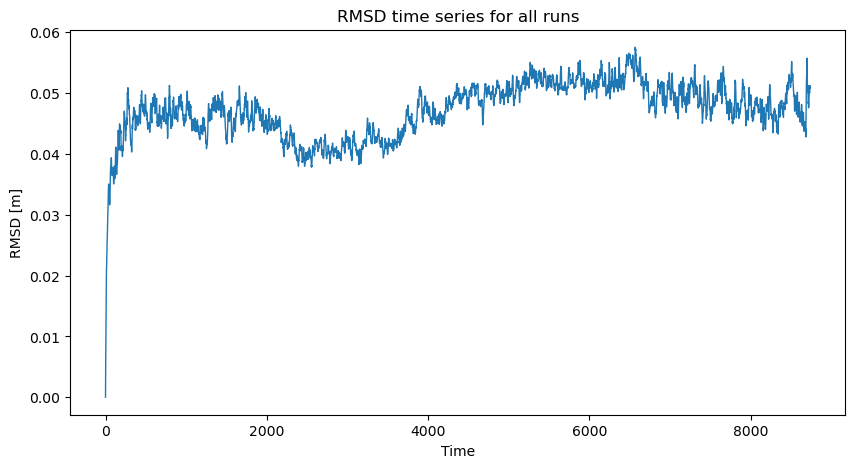

In [17]:
# Plot the RMSE time series for all runs, color them by the CP step using viridis colormap
if do_one_year:
    import matplotlib.cm as cm
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(np.arange(rmse_df.shape[1]), np.median(rmse_df, axis=0), label=f'RMSE', lw=1)
    # ax.set_xlim(0,480)
    ax.set_title(f'RMSD time series for all runs')
    ax.set_xlabel('Time')
    ax.set_ylabel('RMSD [m]')
    # ax.legend(fontsize='small')
    plt.savefig(os.path.join(odir, f'{prefix}zeta_rmsd_timeseries.png'), dpi=100)
    print(f'RMSD time series plot saved to {os.path.join(odir, f"{prefix}zeta_rmsd_timeseries.png")}')
    plt.show()

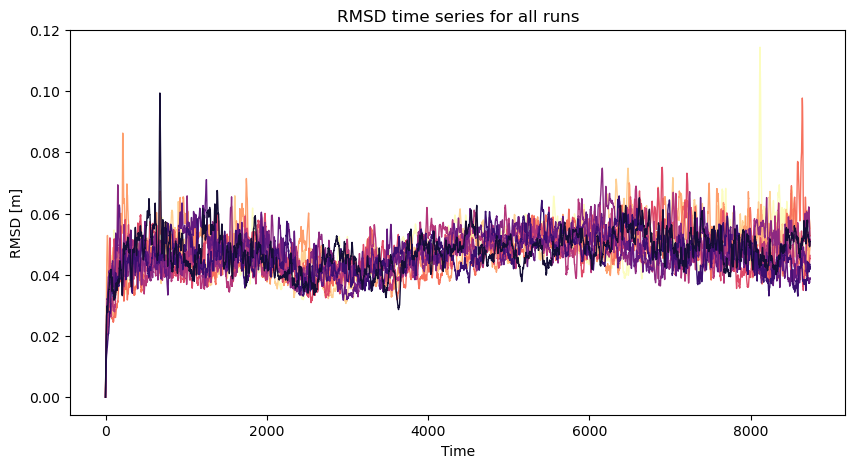

In [27]:
# Plot the RMSE time series for all runs, color them by the CP step using viridis colormap
if do_one_year:
    import matplotlib.cm as cm
    fig, ax = plt.subplots(figsize=(10, 5))
    for ifile_idx in np.arange(rmse_df.shape[0]):
        ax.plot(np.arange(rmse_df.shape[1]), rmse_df.values[ifile_idx, :], lw=1, color=cm.magma_r(ifile_idx/rmse_df.shape[0]))
    ax.set_title(f'RMSD time series for all runs')
    ax.set_xlabel('Time')
    ax.set_ylabel('RMSD [m]')
    # ax.set_xlim(0,2400)
    plt.show()

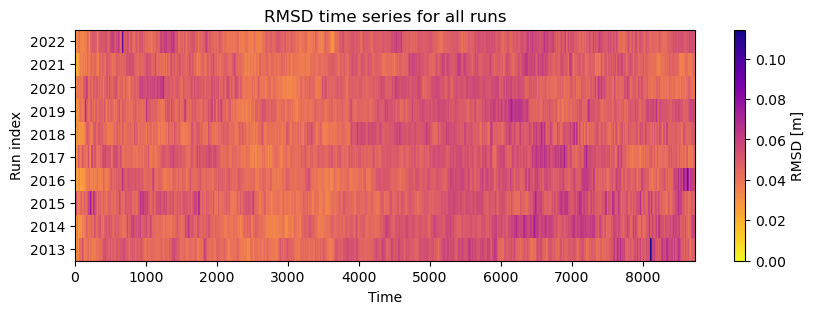

In [28]:
# Plot rmse_df as pcolormesh
if do_one_year:
    fig, ax = plt.subplots(figsize=(10, 3))
    pcm = ax.pcolormesh(rmse_df.columns.astype(int), rmse_df.index, rmse_df.values, cmap='plasma_r')
    ax.set_title(f'RMSD time series for all runs')
    ax.set_xlabel('Time')
    ax.set_ylabel('Run index')
    fig.colorbar(pcm, ax=ax, label='RMSD [m]')
    plt.show()